In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Load data
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
data = pd.read_csv(url, sep=';')
X = data.drop('quality', axis=1)
y = data['quality']

In [ ]:
# Split & scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [ ]:
# Models
models = {
    'Linear': LinearRegression(),
    'Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'RF': RandomForestRegressor(n_estimators=100, random_state=42)
         }

In [ ]:
results = {}
predictions = {}
for name, model in models.items():
    if name == 'Linear':
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {'R²': r2, 'RMSE': rmse}
    predictions[name] = y_pred

print(pd.DataFrame(results).T.round(3))


           R²   RMSE
Linear  0.403  0.625
Tree    0.112  0.762
RF      0.539  0.549


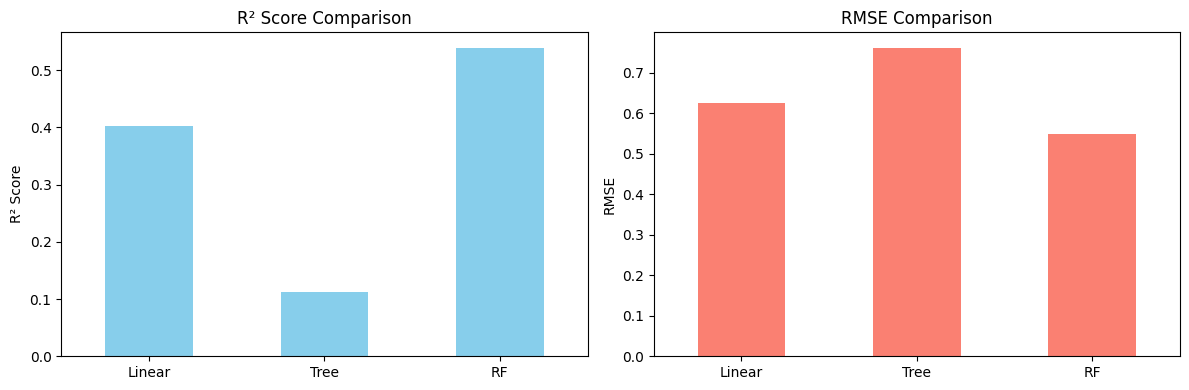

In [ ]:
# Graph 1: Model Performance Bar Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df_results = pd.DataFrame(results).T
df_results['R²'].plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('R² Score Comparison')
ax1.set_ylabel('R² Score')
ax1.tick_params(axis='x', rotation=0)

df_results['RMSE'].plot(kind='bar', ax=ax2, color='salmon')
ax2.set_title('RMSE Comparison')
ax2.set_ylabel('RMSE')
ax2.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

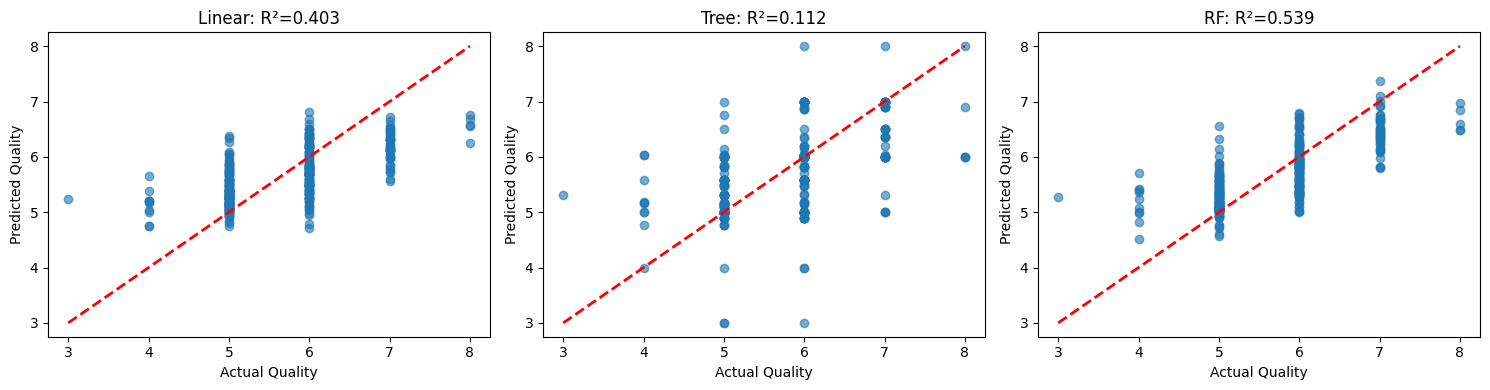

In [ ]:
# Graph 2: Predicted vs Actual (all models)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, y_pred) in enumerate(predictions.items()):
    axes[i].scatter(y_test, y_pred, alpha=0.6)
    axes[i].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    axes[i].set_xlabel('Actual Quality')
    axes[i].set_ylabel('Predicted Quality')
    axes[i].set_title(f'{name}: R²={results[name]["R²"]:.3f}')
plt.tight_layout()
plt.show()

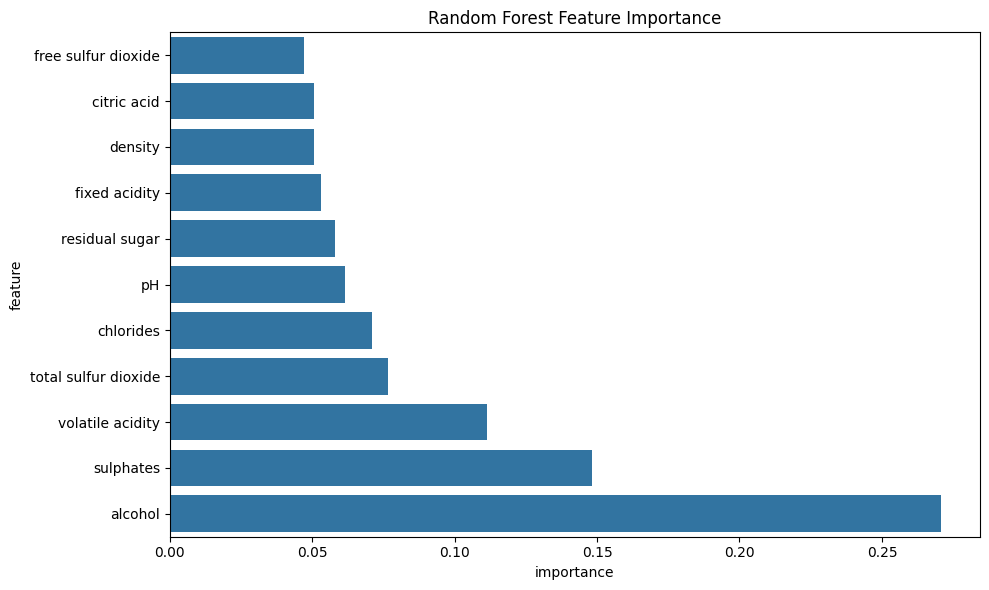

In [ ]:
# Graph 3: Feature Importance (Random Forest)
rf_model = models['RF']
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, y='feature', x='importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()
